In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

**Pulled Data Sets:**

In [2]:
# TEAM SALARIES TABLE ALTERNATE FORM (from data)
team_salaries = []

year = 25
for i in range(11):
    url = "https://www.hoopshype.com/salaries/teams/?season=20" + str(year)
    salary_year = pd.read_html(url)[2]
    salary_year = salary_year.rename(columns={"20"+str(year)+"-"+str(year+1):"Salary"})
    salary_year['Season'] = "20"+str(year)+"-"+str(year+1)
    team_salaries.append(salary_year)
    year-=1

team_salaries = pd.concat(team_salaries).drop('Unnamed: 0', axis=1)
team_salaries['Salary'] = team_salaries['Salary'].str.split('$').str.get(-1).str.split(',').str.join("").astype(int)
salary_year['Team'] = salary_year['Team'].str.split().str.get(-1)
team_salaries = team_salaries.drop(labels=['2026-27', '2027-28', '2028-29'], axis=1)
team_salaries = team_salaries.iloc[:, [0,2,1]]

print(len(team_salaries))
team_salaries.head()

330


,Team,Season,Salary
0,Cavaliers,2025-26,217367467
1,Knicks,2025-26,211398842
2,Warriors,2025-26,208824825
3,Rockets,2025-26,199794378
4,Timberwolves,2025-26,198498074


In [3]:
# TEAM REGULAR SEASON STATS TABLE (from data)
team_stats = []

year = 2026
for i in range(11):
    url = "https://www.basketball-reference.com/leagues/NBA_" + str(year) + "_ratings.html"
    TS_year = pd.read_html(url, index_col=0)[0].droplevel(level=0, axis=1)
    TS_year['Season'] = str(year-1)+"-"+str(year)[-2:]
    year-=1
    team_stats.append(TS_year)

team_stats = pd.concat(team_stats)
team_stats['Team'] = team_stats['Team'].str.split().str.get(-1)
team_stats = team_stats.iloc[:, [0,14,1,2,3,4,5,6,7,8,9,10,11,12,13]]

print(len(team_stats))
team_stats.head()

330


Rk,Team,Season,Conf,Div,W,L,W/L%,MOV,ORtg,DRtg,NRtg,MOV/A,ORtg/A,DRtg/A,NRtg/A
1,Thunder,2025-26,W,NW,64,18,0.780,11.15,118.94,107.89,11.05,11.04,118.73,107.78,10.94
2,Spurs,2025-26,W,SW,62,20,0.756,8.30,119.68,111.41,8.27,8.28,119.65,111.40,8.24
3,Celtics,2025-26,E,A,56,26,0.683,7.70,120.82,112.67,8.15,7.37,120.80,113.00,7.80
4,Pistons,2025-26,E,C,60,22,0.732,8.16,118.05,109.81,8.23,7.53,117.70,110.10,7.60
5,Knicks,2025-26,E,A,53,29,0.646,6.33,119.87,113.40,6.47,6.05,119.85,113.67,6.18


In [4]:
# TEAM PLAYOFF STATS TABLE (from data)
team_playoffs = []

year = 2025
for i in range(10):
    url = "https://www.basketball-reference.com/playoffs/NBA_" + str(year) + ".html#all_totals_team-opponent"
    playoffs_year = pd.read_html(url, index_col=0)[20].droplevel(level=0, axis=1).drop(index=np.nan, axis=0)
    playoffs_year = playoffs_year.drop(playoffs_year.columns[14:23], axis=1)
    playoffs_year['Season'] = str(year-1)+"-"+str(year)[-2:]
    year-=1
    team_playoffs.append(playoffs_year)

team_playoffs = pd.concat(team_playoffs).dropna()
team_playoffs['Tm'] = team_playoffs['Tm'].str.split().str.get(-1)
team_playoffs = team_playoffs.rename(columns={'Tm':'Team'})
team_playoffs['Champ'] = 0
team_playoffs.loc[team_playoffs['W'] == 16, 'Champ'] = 1
team_playoffs = team_playoffs.iloc[:, [0,14,15,1,2,3,4,5,6,7,8,9,10,11,12,13]]

print(len(team_playoffs))
team_playoffs.head()

160


Rk,Team,Season,Champ,Age,W,L,W/L%,PW,PL,ORtg,DRtg,NRtg,Pace,FTr,3PAr,TS%
1.0,Cavaliers,2024-25,0,26.5,5.0,4.0,0.556,7.0,2.0,123.5,111.4,12.1,96.7,0.318,0.467,0.597
2.0,Thunder,2024-25,1,24.7,16.0,7.0,0.696,17.0,6.0,115.4,107.0,8.4,98.9,0.290,0.390,0.566
3.0,Celtics,2024-25,0,29.9,6.0,5.0,0.545,7.0,4.0,114.4,108.4,6.0,91.5,0.273,0.474,0.569
4.0,Timberwolves,2024-25,0,27.6,9.0,6.0,0.600,9.0,6.0,114.6,111.8,2.8,95.1,0.256,0.434,0.574
5.0,Pacers,2024-25,0,26.2,15.0,8.0,0.652,13.0,10.0,115.3,113.3,2.0,98.0,0.292,0.400,0.599


In [5]:
# NAME MAPS (from data)
team_name_map = {
    "ATL": "Hawks",
    "BOS": "Celtics",
    "BKN": "Nets",
    "CHA": "Hornets",
    "CHI": "Bulls",
    "CLE": "Cavaliers",
    "DAL": "Mavericks",
    "DEN": "Nuggets",
    "DET": "Pistons",
    "GSW": "Warriors",
    "HOU": "Rockets",
    "IND": "Pacers",
    "LAC": "Clippers",
    "LAL": "Lakers",
    "MEM": "Grizzlies",
    "MIA": "Heat",
    "MIL": "Bucks",
    "MIN": "Timberwolves",
    "NOP": "Pelicans",
    "NYK": "Knicks",
    "OKC": "Thunder",
    "ORL": "Magic",
    "PHI": "76ers",
    "PHX": "Suns",
    "POR": "Blazers",
    "SAC": "Kings",
    "SAS": "Spurs",
    "TOR": "Raptors",
    "UTA": "Jazz",
    "WAS": "Wizards",
    "2TM": "2TM",
    "3TM": "3TM"
}

player_name_map = {
    "Nikola Jokić": "Nikola Jokic",
    "Luka Dončić": "Luka Doncic",
    "Jonas Valančiūnas": "Jonas Valanciunas",
    "Nikola Vučević": "Nikola Vucevic",
}

In [6]:
# REGULAR SEASON PLAYER DATA (from data)
regular_szn_stats = []

year=2026
for i in range(11):
    url = "https://www.basketball-reference.com/leagues/NBA_" +str(year)+ "_per_game.html"

    df = pd.read_html(url)[0]

    df = df[df["Rk"] != "Rk"].copy()

    multi_team_players = df.loc[df["Team"].isin(["2TM", "3TM"]), "Player"]

    df_clean = df[
    ((df["Player"].isin(multi_team_players)) & (df["Team"].isin(["2TM", "3TM"]))) |
    (~df["Player"].isin(multi_team_players))
    ].copy()

    df_clean.reset_index(drop=True, inplace=True)

    df_clean = df_clean.drop(index=len(df_clean)-1, axis=0).drop(columns=['Rk', 'Awards'])

    df_clean['Season'] = str(year-1)+"-"+str(year)[-2:]
    year-=1

    regular_szn_stats.append(df_clean)

p_regular_szn_stats = pd.concat(regular_szn_stats)
p_regular_szn_stats["Team"] = p_regular_szn_stats["Team"].replace(team_name_map)
p_regular_szn_stats["Player"] = p_regular_szn_stats["Player"].replace(player_name_map)

print(len(p_regular_szn_stats))
p_regular_szn_stats.head()

5980


,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Season
0,Luka Doncic,26.0,Lakers,PG,64.0,64.0,35.8,10.8,22.8,0.476,...,0.6,7.1,7.7,8.3,1.6,0.5,4.0,2.4,33.5,2025-26
1,Shai Gilgeous-Alexander,27.0,Thunder,PG,68.0,68.0,33.2,10.8,19.4,0.553,...,0.6,3.7,4.3,6.6,1.4,0.8,2.2,2.0,31.1,2025-26
2,Anthony Edwards,24.0,Timberwolves,SG,61.0,60.0,35.0,9.9,20.2,0.489,...,0.6,4.4,5.0,3.7,1.4,0.8,2.9,1.9,28.8,2025-26
3,Jaylen Brown,29.0,Celtics,SF,71.0,71.0,34.4,10.4,21.7,0.477,...,1.1,5.8,6.9,5.1,1.0,0.4,3.6,2.7,28.7,2025-26
4,Tyrese Maxey,25.0,76ers,PG,70.0,70.0,38.0,9.9,21.4,0.462,...,0.3,3.8,4.1,6.6,1.9,0.8,2.4,2.2,28.3,2025-26


In [7]:
# PLAYOFF PLAYER DATA (from data)
p_playoff_stats = []

year=2025
for i in range(10):
    url = "https://www.basketball-reference.com/leagues/NBA_" + str(year) + "_per_game.html"

    df = pd.read_html(url)[1]

    df = df[df["Rk"] != "Rk"].copy()

    multi_team_players = df.loc[df["Team"].isin(["2TM", "3TM"]), "Player"]

    df_clean = df[
    ((df["Player"].isin(multi_team_players)) & (df["Team"].isin(["2TM", "3TM"]))) |
    (~df["Player"].isin(multi_team_players))
    ].copy()

    df_clean.reset_index(drop=True, inplace=True)

    df_clean = df_clean.drop(index=len(df_clean)-1, axis=0).drop(columns=['Rk', 'Awards'])

    df_clean['Season'] = str(year-1)+"-"+str(year)[-2:]
    year-=1

    p_playoff_stats.append(df_clean)

p_playoff_stats = pd.concat(p_playoff_stats)
p_playoff_stats["Team"] = p_playoff_stats["Team"].replace(team_name_map)
p_playoff_stats["Player"] = p_playoff_stats["Player"].replace(player_name_map)

print(len(p_playoff_stats))
p_playoff_stats.head()

2175


,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Season
0,Giannis Antetokounmpo,30.0,Bucks,PF,5.0,5.0,37.6,12.0,19.8,0.606,...,3.8,11.6,15.4,6.6,1.0,1.0,4.6,2.4,33.0,2024-25
1,Luka Doncic,25.0,Lakers,PG,5.0,5.0,41.6,9.4,20.8,0.452,...,0.4,6.6,7.0,5.8,1.0,0.6,4.0,3.2,30.2,2024-25
2,Shai Gilgeous-Alexander,26.0,Thunder,PG,23.0,23.0,37.0,10.1,21.9,0.462,...,1.0,4.3,5.3,6.5,1.7,0.9,2.6,2.8,29.9,2024-25
3,Donovan Mitchell,28.0,Cavaliers,SG,9.0,9.0,32.0,9.6,21.6,0.443,...,1.2,3.4,4.7,3.9,1.9,0.3,1.9,2.0,29.6,2024-25
4,Paolo Banchero,22.0,Magic,PF,5.0,5.0,39.4,10.8,24.8,0.435,...,2.4,6.0,8.4,4.2,0.6,0.8,3.0,3.6,29.4,2024-25


In [8]:
# PLAYER SALARIES (from data)
def get_year_salaries_until_stop(year):
    pages = []

    for page in range(1, 15):
        url = f"https://www.espn.com/nba/salaries/_/year/{year}/page/{page}/seasontype/5"
        try:
            tables = pd.read_html(url)
        except Exception:
            break

        df = tables[0].copy()

        if df.empty:
            break

        pages.append(df)

    if pages:
        return pd.concat(pages, ignore_index=True)
    return pd.DataFrame()

player_salaries = []

year = 2026
for i in range(11):
    df = get_year_salaries_until_stop(year)
    df["Season"] = str(year-1)+"-"+str(year)[-2:]
    player_salaries.append(df)
    year-=1

player_salaries = pd.concat(player_salaries)
player_salaries = player_salaries[player_salaries.loc[:,1] != 'NAME'].drop(columns=0)
player_salaries = player_salaries.rename(columns={1:'Player', 2:'Team', 3:'Salary'})
player_salaries['Player'] = player_salaries['Player'].str.split(',').str.get(0)
player_salaries['Salary'] = player_salaries['Salary'].str.split('$').str.get(-1).str.split(',').str.join("").astype(int)
player_salaries['Team'] = player_salaries['Team'].str.split().str.get(-1)

print(len(player_salaries))
player_salaries.head()

5664


,Player,Team,Salary,Season
1,Stephen Curry,Warriors,59606817,2025-26
2,Joel Embiid,76ers,55224526,2025-26
3,Nikola Jokic,Nuggets,55224526,2025-26
4,Kevin Durant,Rockets,54708609,2025-26
5,Anthony Davis,Mavericks,54126450,2025-26


**Merged Data (for our use):**

In [9]:
# TEAM REGULAR SEASON STATS + SALARIES
t_regular_szn_data = team_stats.merge(team_salaries, on=['Season', 'Team'])
print(len(t_regular_szn_data))
t_regular_szn_data.head()

319


,Team,Season,Conf,Div,W,L,W/L%,MOV,ORtg,DRtg,NRtg,MOV/A,ORtg/A,DRtg/A,NRtg/A,Salary
0,Thunder,2025-26,W,NW,64,18,0.780,11.15,118.94,107.89,11.05,11.04,118.73,107.78,10.94,190319298
1,Spurs,2025-26,W,SW,62,20,0.756,8.30,119.68,111.41,8.27,8.28,119.65,111.40,8.24,187455363
2,Celtics,2025-26,E,A,56,26,0.683,7.70,120.82,112.67,8.15,7.37,120.80,113.00,7.80,190096720
3,Pistons,2025-26,E,C,60,22,0.732,8.16,118.05,109.81,8.23,7.53,117.70,110.10,7.60,188270076
4,Knicks,2025-26,E,A,53,29,0.646,6.33,119.87,113.40,6.47,6.05,119.85,113.67,6.18,211398842


In [10]:
# TEAM PLAYOFF STATS + SALARIES
t_playoff_data = team_playoffs.merge(team_salaries, on=['Season', 'Team'])
t_playoff_data['W'] = t_playoff_data['W'].astype(int)
t_playoff_data["Salary Ranking"] = (t_playoff_data.groupby("Season")["Salary"].rank(method="first", ascending=True).astype(int))
print(len(t_playoff_data))
t_playoff_data.head()

154


,Team,Season,Champ,Age,W,L,W/L%,PW,PL,ORtg,DRtg,NRtg,Pace,FTr,3PAr,TS%,Salary,Salary Ranking
0,Cavaliers,2024-25,0,26.5,5,4.0,0.556,7.0,2.0,123.5,111.4,12.1,96.7,0.318,0.467,0.597,165110486,4
1,Thunder,2024-25,1,24.7,16,7.0,0.696,17.0,6.0,115.4,107.0,8.4,98.9,0.290,0.390,0.566,166418720,6
2,Celtics,2024-25,0,29.9,6,5.0,0.545,7.0,4.0,114.4,108.4,6.0,91.5,0.273,0.474,0.569,195348491,15
3,Timberwolves,2024-25,0,27.6,9,6.0,0.600,9.0,6.0,114.6,111.8,2.8,95.1,0.256,0.434,0.574,203708244,16
4,Pacers,2024-25,0,26.2,15,8.0,0.652,13.0,10.0,115.3,113.3,2.0,98.0,0.292,0.400,0.599,169543082,7


In [11]:
# PLAYER REGULAR SEASON STATS + SALARIES
p_regular_szn_data = player_salaries.merge(p_regular_szn_stats.drop(columns='Team'), on=['Player', 'Season'])
print(len(p_regular_szn_data))
p_regular_szn_data.head()

4651


,Player,Team,Salary,Season,Age,Pos,G,GS,MP,FG,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Stephen Curry,Warriors,59606817,2025-26,37.0,PG,43.0,41.0,30.9,8.7,...,0.923,0.4,3.2,3.6,4.7,1.1,0.4,2.8,1.7,26.6
1,Joel Embiid,76ers,55224526,2025-26,31.0,C,38.0,38.0,31.6,9.0,...,0.854,2.0,5.7,7.7,3.9,0.6,1.2,2.9,2.2,26.9
2,Nikola Jokic,Nuggets,55224526,2025-26,30.0,C,65.0,65.0,34.8,9.9,...,0.831,3.0,9.9,12.9,10.7,1.4,0.8,3.7,2.7,27.7
3,Kevin Durant,Rockets,54708609,2025-26,37.0,SF,78.0,78.0,36.4,9.2,...,0.874,0.5,4.9,5.5,4.8,0.8,0.9,3.2,1.8,26.0
4,Anthony Davis,Mavericks,54126450,2025-26,32.0,PF,20.0,20.0,31.3,8.5,...,0.728,3.1,8.0,11.1,2.8,1.1,1.7,2.1,2.1,20.4


In [12]:
# PLAYER PLAYOFF STATS + SALARIES
p_playoff_data = player_salaries.merge(p_playoff_stats.drop(columns='Team'), on=['Player', 'Season'])
print(len(p_playoff_data))
p_playoff_data.head()

1917


,Player,Team,Salary,Season,Age,Pos,G,GS,MP,FG,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Stephen Curry,Warriors,55761216,2024-25,36.0,PG,8.0,8.0,35.1,7.8,...,0.893,0.3,5.0,5.3,5.1,1.0,0.8,3.4,1.6,22.6
1,Nikola Jokic,Nuggets,51415938,2024-25,29.0,C,14.0,14.0,40.2,9.4,...,0.772,2.1,10.6,12.7,8.0,2.0,0.9,3.9,3.4,26.2
2,Kawhi Leonard,Clippers,49350000,2024-25,33.0,SF,7.0,7.0,37.9,9.4,...,0.778,1.6,6.0,7.6,4.7,1.1,0.7,2.1,1.7,25.0
3,Karl-Anthony Towns,Knicks,49205800,2024-25,29.0,C,18.0,18.0,35.5,7.7,...,0.845,2.1,9.5,11.6,1.3,0.7,0.7,2.2,4.3,21.4
4,Jaylen Brown,Celtics,49205800,2024-25,28.0,SF,11.0,11.0,36.5,7.8,...,0.758,1.2,5.9,7.1,3.9,1.0,0.3,3.5,3.2,22.1


In [ ]:
# CHAMPIONSHIP TEAM PLAYER SALARY DATA
championship_teams = t_playoff_data[t_playoff_data['Champ']== 1][['Team', 'Season', 'Salary']].rename(columns={'Salary': 'Team Salary'})
championship_salaries = championship_teams.merge(p_regular_szn_data[['Team', 'Season', 'Player', 'Salary', 'Pos']]).rename(columns={'Salary': 'Player Salary'})
championship_salaries['Player Salary Ratio'] = championship_salaries['Player Salary']/championship_salaries['Team Salary']
print(len(championship_salaries))
championship_salaries.head()

145


,Team,Season,Team Salary,Player,Player Salary,Pos,Player Salary Ratio
0,Thunder,2024-25,166418720,Shai Gilgeous-Alexander,35859950,PG,0.215480
1,Thunder,2024-25,166418720,Isaiah Hartenstein,30000000,C,0.180268
2,Thunder,2024-25,166418720,Luguentz Dort,16500000,SF,0.099147
3,Thunder,2024-25,166418720,Isaiah Joe,12991650,SG,0.078066
4,Thunder,2024-25,166418720,Chet Holmgren,10880640,C,0.065381


**Calculations/Usage of Data:**

In [14]:
p_regular_szn_data.groupby("Season")['Salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
2015-16,418.0,4.758156e+06,5.301826e+06,30888.0,981348.00,2547210.0,6447715.5,25000000.0
2016-17,408.0,6.309936e+06,6.679769e+06,83119.0,1052342.00,3530626.5,9621355.5,30963450.0
2017-18,362.0,7.768352e+06,7.903795e+06,375000.0,1544951.00,4171659.5,12294214.0,37457154.0
2018-19,422.0,7.139422e+06,8.161076e+06,4737.0,1512601.00,3362124.5,10571629.5,37457154.0
2019-20,413.0,7.752388e+06,8.993762e+06,155647.0,1620564.00,3569643.0,10500000.0,40231758.0
2020-21,431.0,7.697679e+06,9.317796e+06,11898.0,1620564.00,3631200.0,9655751.0,43006362.0
2021-22,445.0,7.703286e+06,9.441057e+06,5318.0,1669178.00,3804360.0,9720900.0,45780966.0
2022-23,449.0,8.614340e+06,1.042471e+07,8558.0,1836090.00,4004280.0,10552800.0,48070014.0
2023-24,430.0,1.017788e+07,1.145019e+07,289542.0,2165000.00,5165236.5,12500000.0,51915615.0


In [15]:
pos_order = ['PG', 'SG', 'SF', 'PF', 'C']
p_regular_szn_data.pivot_table('Salary', index="Pos", columns='Season', aggfunc='max').reindex(pos_order)

Season,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26
Pos,,,,,,,,,,,
PG,21468695,26540100,37457154,37457154,40231758,43006362,45780966,48070014,51915615,55761216,59606817
SG,20000000,26540100,28299399,27739975,38199000,29467800,37980720,43279250,46741590,50203930,53142264
SF,25000000,30963450,29727900,35654150,32742000,35450412,35500000,42492492,45640084,49350000,54708609
PF,22192730,26540100,32088932,32088932,34449964,40108950,42018900,44474988,47649433,51179021,54126450
C,22359364,26540100,27734406,28928709,28000000,29592696,41180544,38172414,47607350,51415938,55224526


In [16]:
p_regular_szn_data[p_regular_szn_data['Player'] == 'Stephen Curry']

,Player,Team,Salary,Season,Age,Pos,G,GS,MP,FG,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Stephen Curry,Warriors,59606817,2025-26,37.0,PG,43.0,41.0,30.9,8.7,...,0.923,0.4,3.2,3.6,4.7,1.1,0.4,2.8,1.7,26.6
429,Stephen Curry,Warriors,55761216,2024-25,36.0,PG,70.0,70.0,32.2,8.1,...,0.933,0.6,3.9,4.4,6.0,1.1,0.4,2.9,1.4,24.5
873,Stephen Curry,Warriors,51915615,2023-24,35.0,PG,74.0,74.0,32.7,8.8,...,0.923,0.5,4.0,4.5,5.1,0.7,0.4,2.8,1.6,26.4
1303,Stephen Curry,Warriors,48070014,2022-23,34.0,PG,56.0,56.0,34.7,10.0,...,0.915,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4
1752,Stephen Curry,Warriors,45780966,2021-22,33.0,PG,64.0,64.0,34.5,8.4,...,0.923,0.5,4.7,5.2,6.3,1.3,0.4,3.2,2.0,25.5
2197,Stephen Curry,Warriors,43006362,2020-21,32.0,PG,63.0,63.0,34.2,10.4,...,0.916,0.5,5.0,5.5,5.8,1.2,0.1,3.4,1.9,32.0
2628,Stephen Curry,Warriors,40231758,2019-20,31.0,PG,5.0,5.0,27.8,6.6,...,1.000,0.8,4.4,5.2,6.6,1.0,0.4,3.2,2.2,20.8
3041,Stephen Curry,Warriors,37457154,2018-19,30.0,PG,69.0,69.0,33.8,9.2,...,0.916,0.7,4.7,5.3,5.2,1.3,0.4,2.8,2.4,27.3
3463,Stephen Curry,Warriors,37457154,2017-18,29.0,PG,51.0,51.0,32.0,8.4,...,0.921,0.7,4.4,5.1,6.1,1.6,0.2,3.0,2.2,26.4
3901,Stephen Curry,Warriors,12112359,2016-17,28.0,PG,79.0,79.0,33.4,8.5,...,0.898,0.8,3.7,4.5,6.6,1.8,0.2,3.0,2.3,25.3


In [17]:
p_regular_szn_data.pivot_table('Salary', index="Pos", columns='Season', aggfunc='median').reindex(pos_order)

Season,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26
Pos,,,,,,,,,,,
PG,2399040.0,3386598.0,4221000.0,3437580.0,5327563.5,6000000.0,5495532.0,4833600.0,5999455.5,7152094.5,5685000.0
SG,2148360.0,3101940.0,4001740.0,3078840.0,2803357.0,2816760.0,3261480.0,4000000.0,4423440.0,4041249.0,4831558.5
SF,2288205.0,4264057.0,3853931.0,2791440.0,2475840.0,2954700.0,3053760.0,3987119.0,4556983.0,5200000.0,7278846.0
PF,2825093.0,3800000.0,3974999.5,4320500.0,3576277.5,3837260.0,3676852.0,4325100.5,5709877.0,8000000.0,6914260.0
C,2943221.0,4000000.0,4593799.5,4350000.0,4767000.0,5000000.0,3277080.0,3200000.0,5302096.0,5007280.0,5850540.0


In [18]:
# TOP 3 INDEX & TEAM TYPE CALCULATIONS
# regular season
top3 = (
    p_regular_szn_data.sort_values(["Season", "Team", "Salary"], ascending=[True, True, False])
    .groupby(["Season", "Team"])
    .head(3)
    .groupby(["Season", "Team"], as_index=False)["Salary"]
    .sum()
    .rename(columns={"Salary": "Top3Salary"})
)

team_totals = team_salaries.rename(columns={"Salary": "TotalSalary"})

salary_structure = top3.merge(team_totals, on=["Season", "Team"], how="inner")
salary_structure["TopHeavyIndex"] = salary_structure["Top3Salary"] / salary_structure["TotalSalary"]

analysis_df_reg = salary_structure.merge(
    team_stats[['Season', 'Team', 'W', 'L', 'W/L%']],
    on=["Season", "Team"],
    how="inner"
)

analysis_df_reg["CostPerWin"] = analysis_df_reg["TotalSalary"] / analysis_df_reg["W"]

q1 = analysis_df_reg["TopHeavyIndex"].quantile(0.25)
q3 = analysis_df_reg["TopHeavyIndex"].quantile(0.75)

def categorize(x):
    if x >= q3:
        return "Superstar-Heavy"
    elif x <= q1:
        return "Balanced Roster"
    else:
        return "Middle"

analysis_df_reg["TeamType"] = analysis_df_reg["TopHeavyIndex"].apply(categorize)

prop_df_reg = (
    analysis_df_reg
    .groupby(["Season", "TeamType"])
    .size()
    .reset_index(name="Count")
)

prop_df_reg["Proportion"] = prop_df_reg.groupby("Season")["Count"].transform(lambda x: x / x.sum())

# playoff
top3 = (
    p_playoff_data.sort_values(["Season", "Team", "Salary"], ascending=[True, True, False])
    .groupby(["Season", "Team"])
    .head(3)
    .groupby(["Season", "Team"], as_index=False)["Salary"]
    .sum()
    .rename(columns={"Salary": "Top3Salary"})
)

team_totals = team_salaries.rename(columns={"Salary": "TotalSalary"})

salary_structure = top3.merge(team_totals, on=["Season", "Team"], how="inner")
salary_structure["TopHeavyIndex"] = salary_structure["Top3Salary"] / salary_structure["TotalSalary"]

analysis_df_playoff = salary_structure.merge(
    team_stats[['Season', 'Team', 'W', 'L', 'W/L%']],
    on=["Season", "Team"],
    how="inner"
)

analysis_df_playoff["CostPerWin"] = analysis_df_playoff["TotalSalary"] / analysis_df_playoff["W"]

q1 = analysis_df_playoff["TopHeavyIndex"].quantile(0.25)
q3 = analysis_df_playoff["TopHeavyIndex"].quantile(0.75)

def categorize(x):
    if x >= q3:
        return "Superstar-Heavy"
    elif x <= q1:
        return "Balanced Roster"
    else:
        return "Middle"

analysis_df_playoff["TeamType"] = analysis_df_playoff["TopHeavyIndex"].apply(categorize)

prop_df_playoff = (
    analysis_df_playoff
    .groupby(["Season", "TeamType"])
    .size()
    .reset_index(name="Count")
)

prop_df_playoff["Proportion"] = prop_df_playoff.groupby("Season")["Count"].transform(lambda x: x / x.sum())

In [19]:
championship_teams_types = championship_teams.merge(analysis_df_playoff)
championship_teams_types

,Team,Season,Team Salary,Top3Salary,TotalSalary,TopHeavyIndex,W,L,W/L%,CostPerWin,TeamType
0,Thunder,2024-25,166418720,82359950,166418720,0.494896,68,14,0.829,2.447334e+06,Middle
1,Celtics,2023-24,186940921,101292124,186940921,0.541840,64,18,0.780,2.920952e+06,Middle
2,Nuggets,2022-23,162338665,95611554,162338665,0.588964,53,29,0.646,3.062994e+06,Middle
3,Warriors,2021-22,178980766,115341076,178980766,0.644433,53,29,0.646,3.376996e+06,Superstar-Heavy
4,Bucks,2020-21,136623929,86810925,136623929,0.635401,46,26,0.639,2.970085e+06,Superstar-Heavy
5,Lakers,2019-20,123971686,79164022,123971686,0.638565,52,19,0.732,2.384071e+06,Superstar-Heavy
6,Raptors,2018-19,137793831,78433092,137793831,0.569206,58,24,0.707,2.375756e+06,Middle
7,Warriors,2017-18,137610134,72752869,137610134,0.528688,58,24,0.707,2.372589e+06,Middle
8,Warriors,2016-17,101584835,58534110,101584835,0.576209,67,15,0.817,1.516192e+06,Middle
9,Cavaliers,2015-16,108300458,59067001,108300458,0.545399,57,25,0.695,1.900008e+06,Middle


**All Plots in Report:**

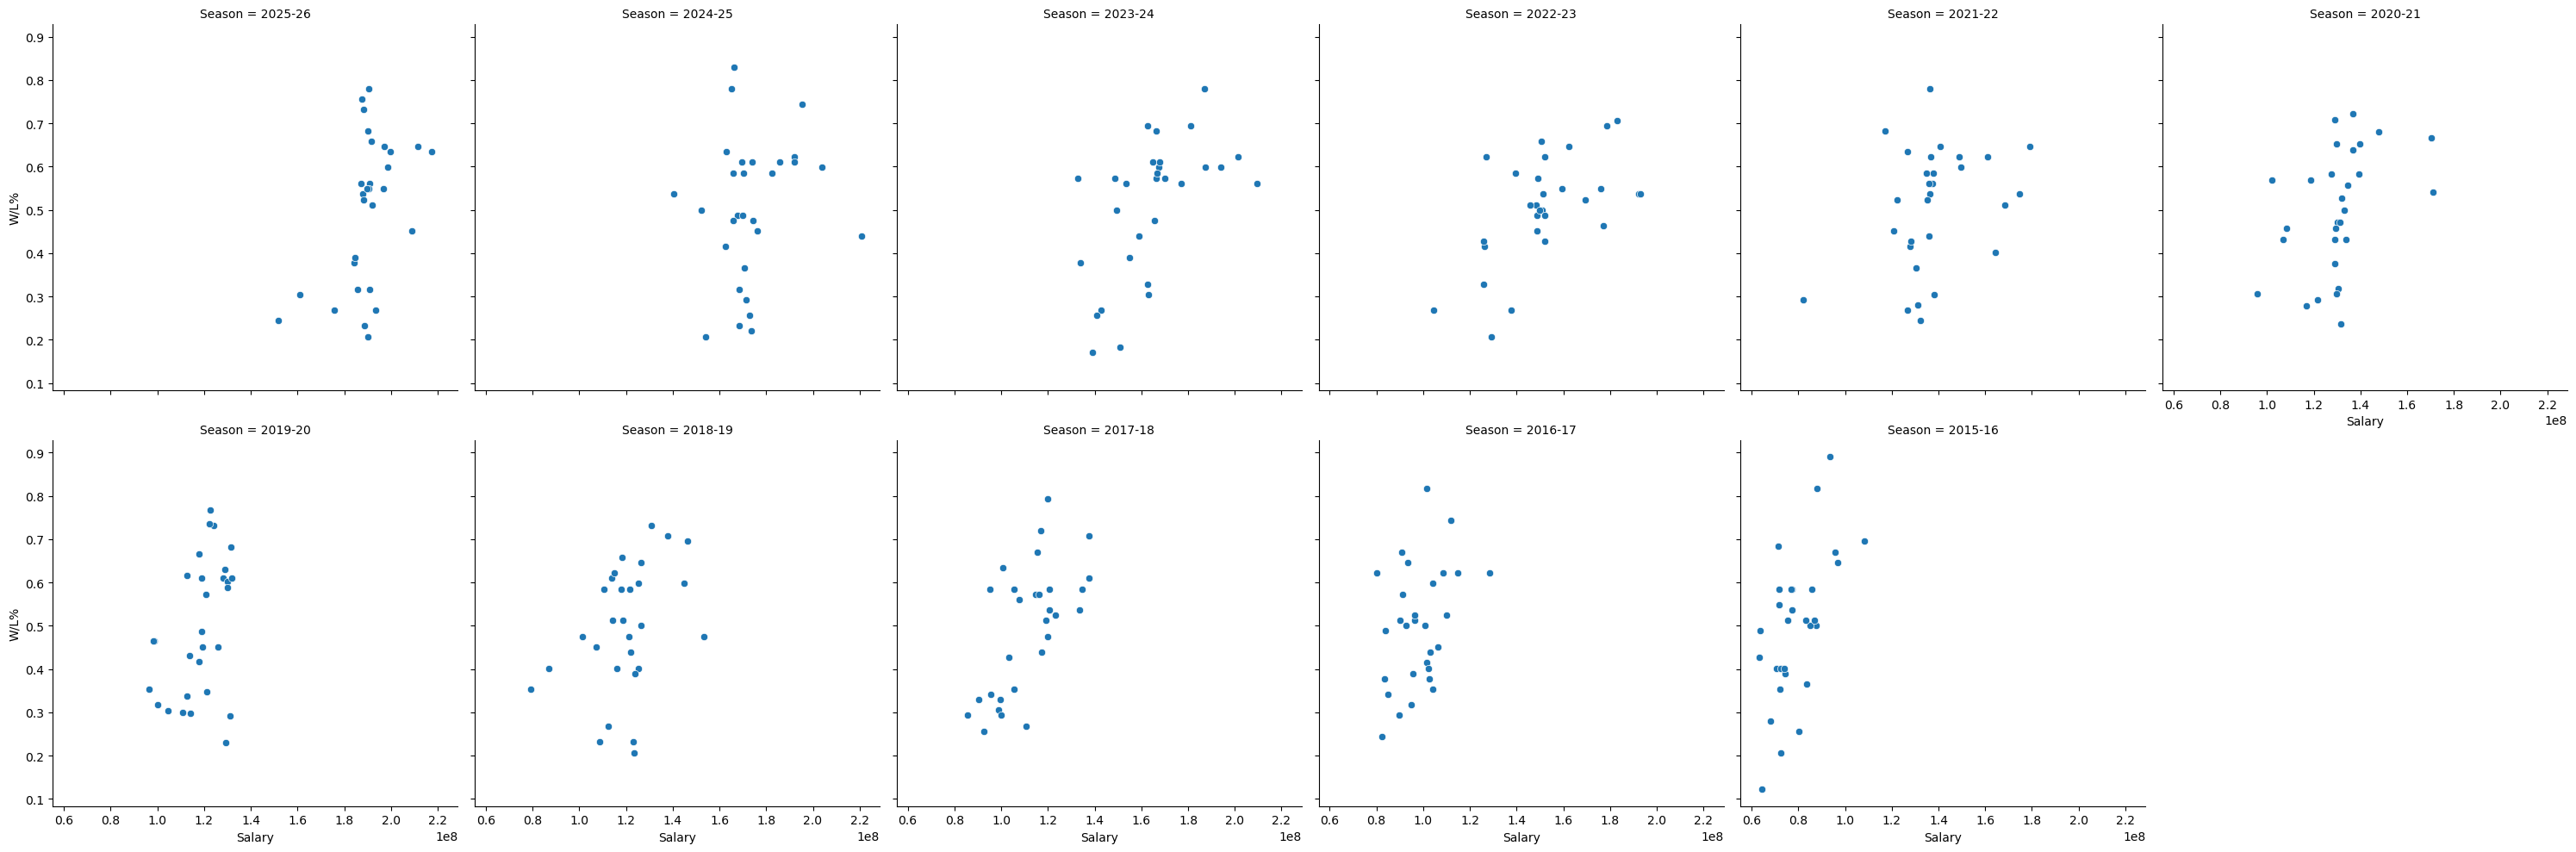

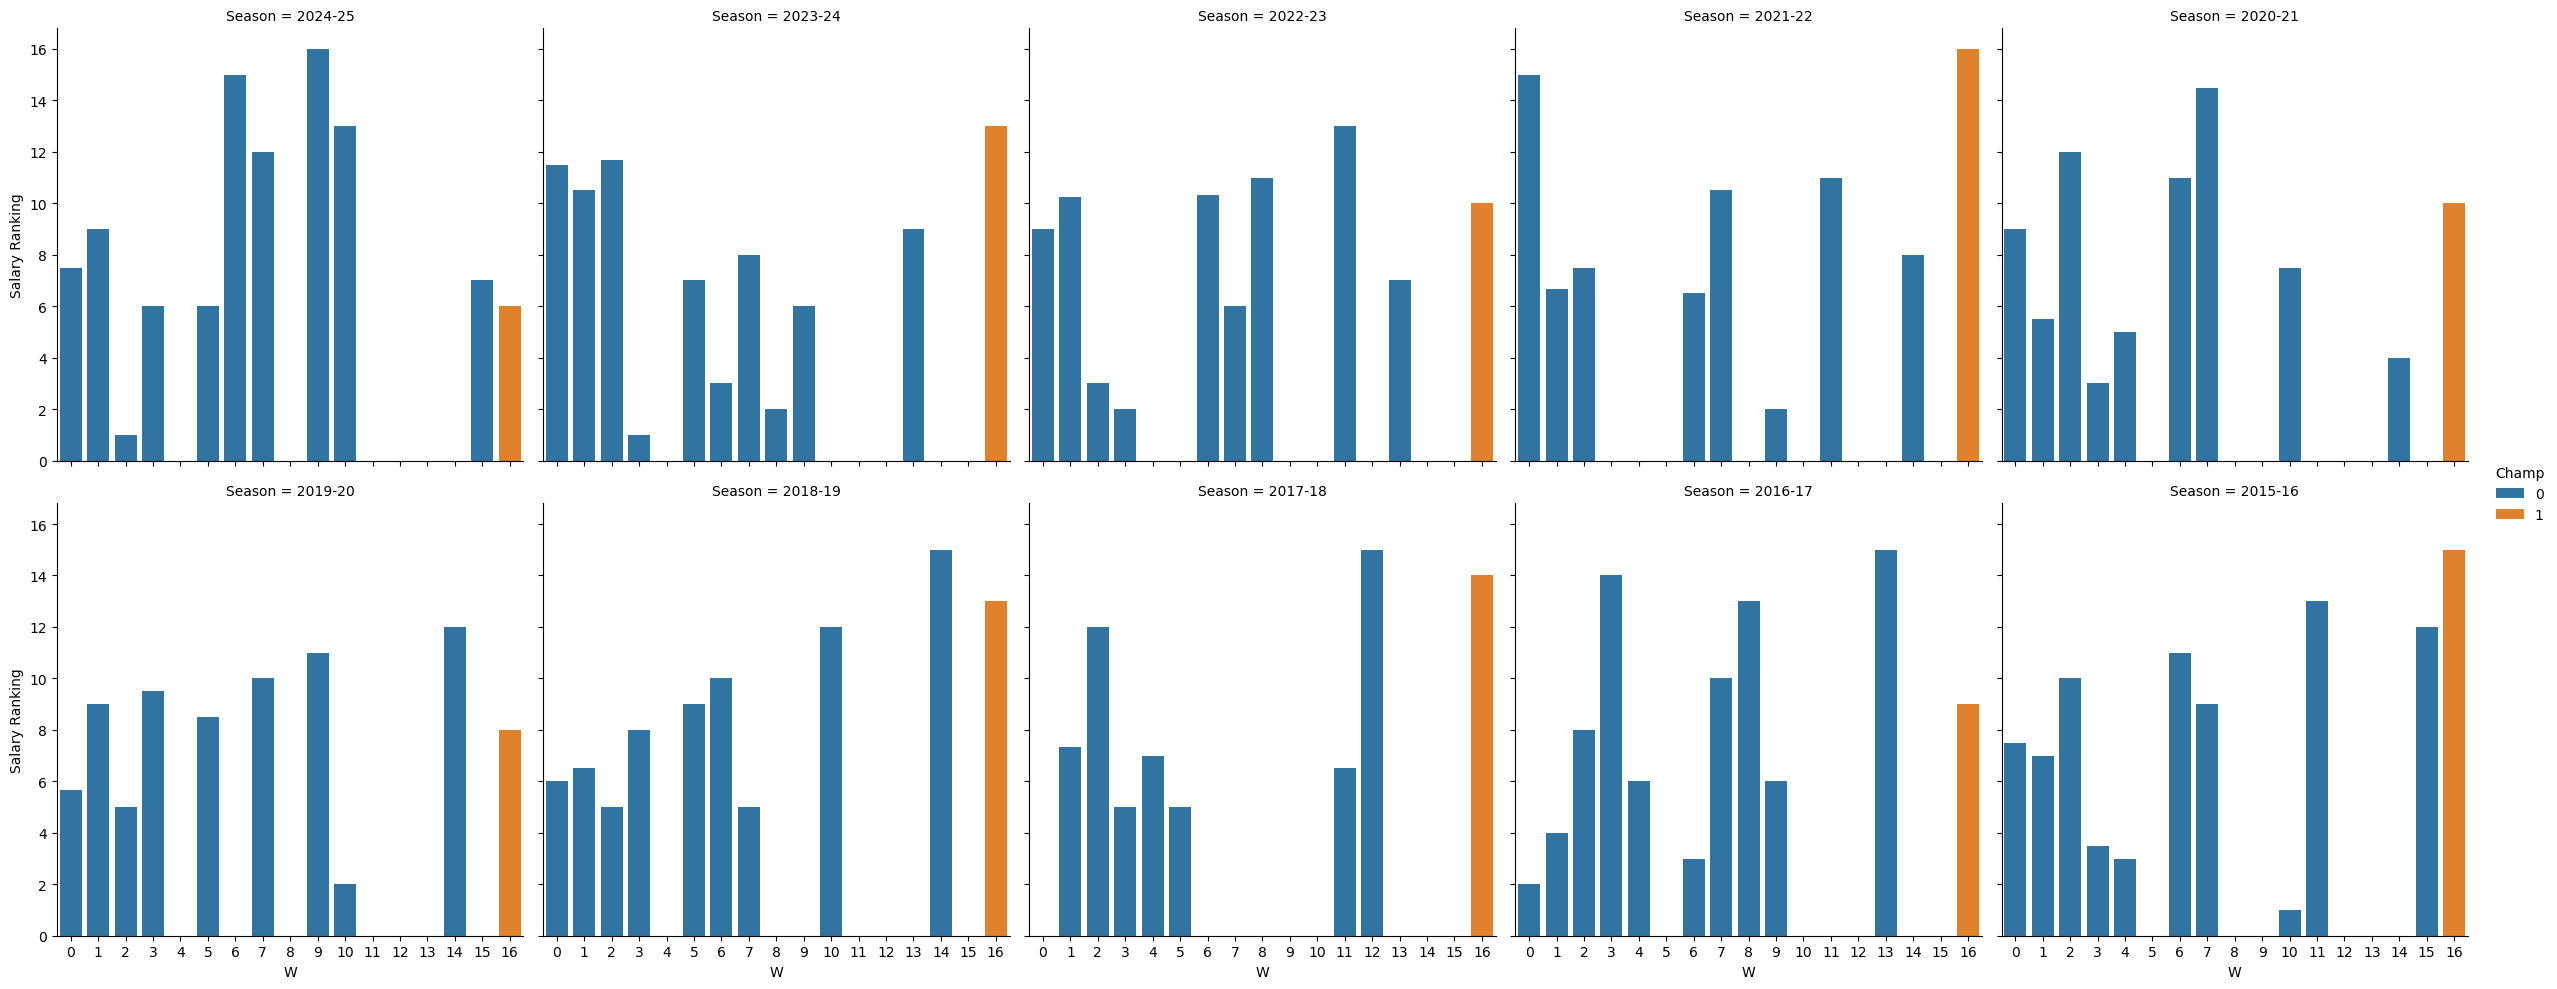

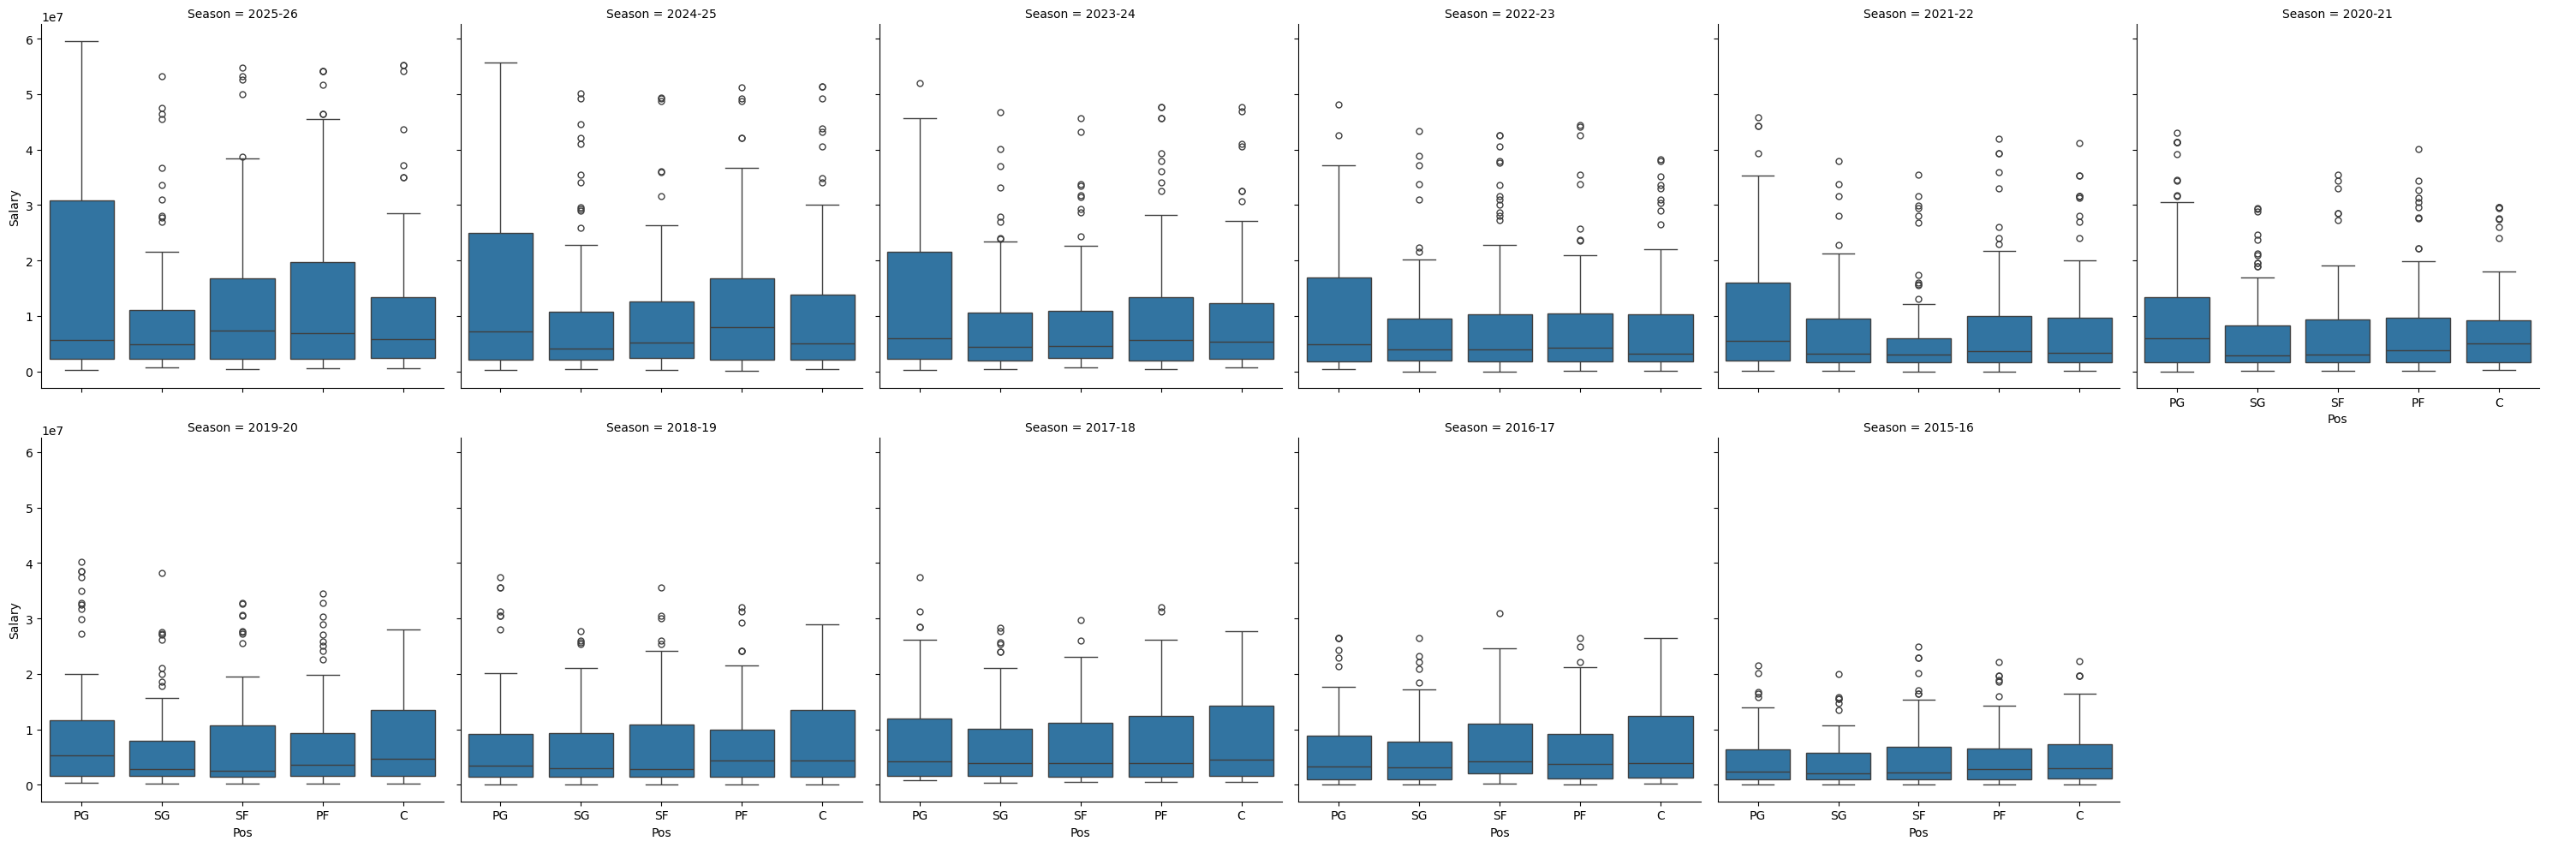

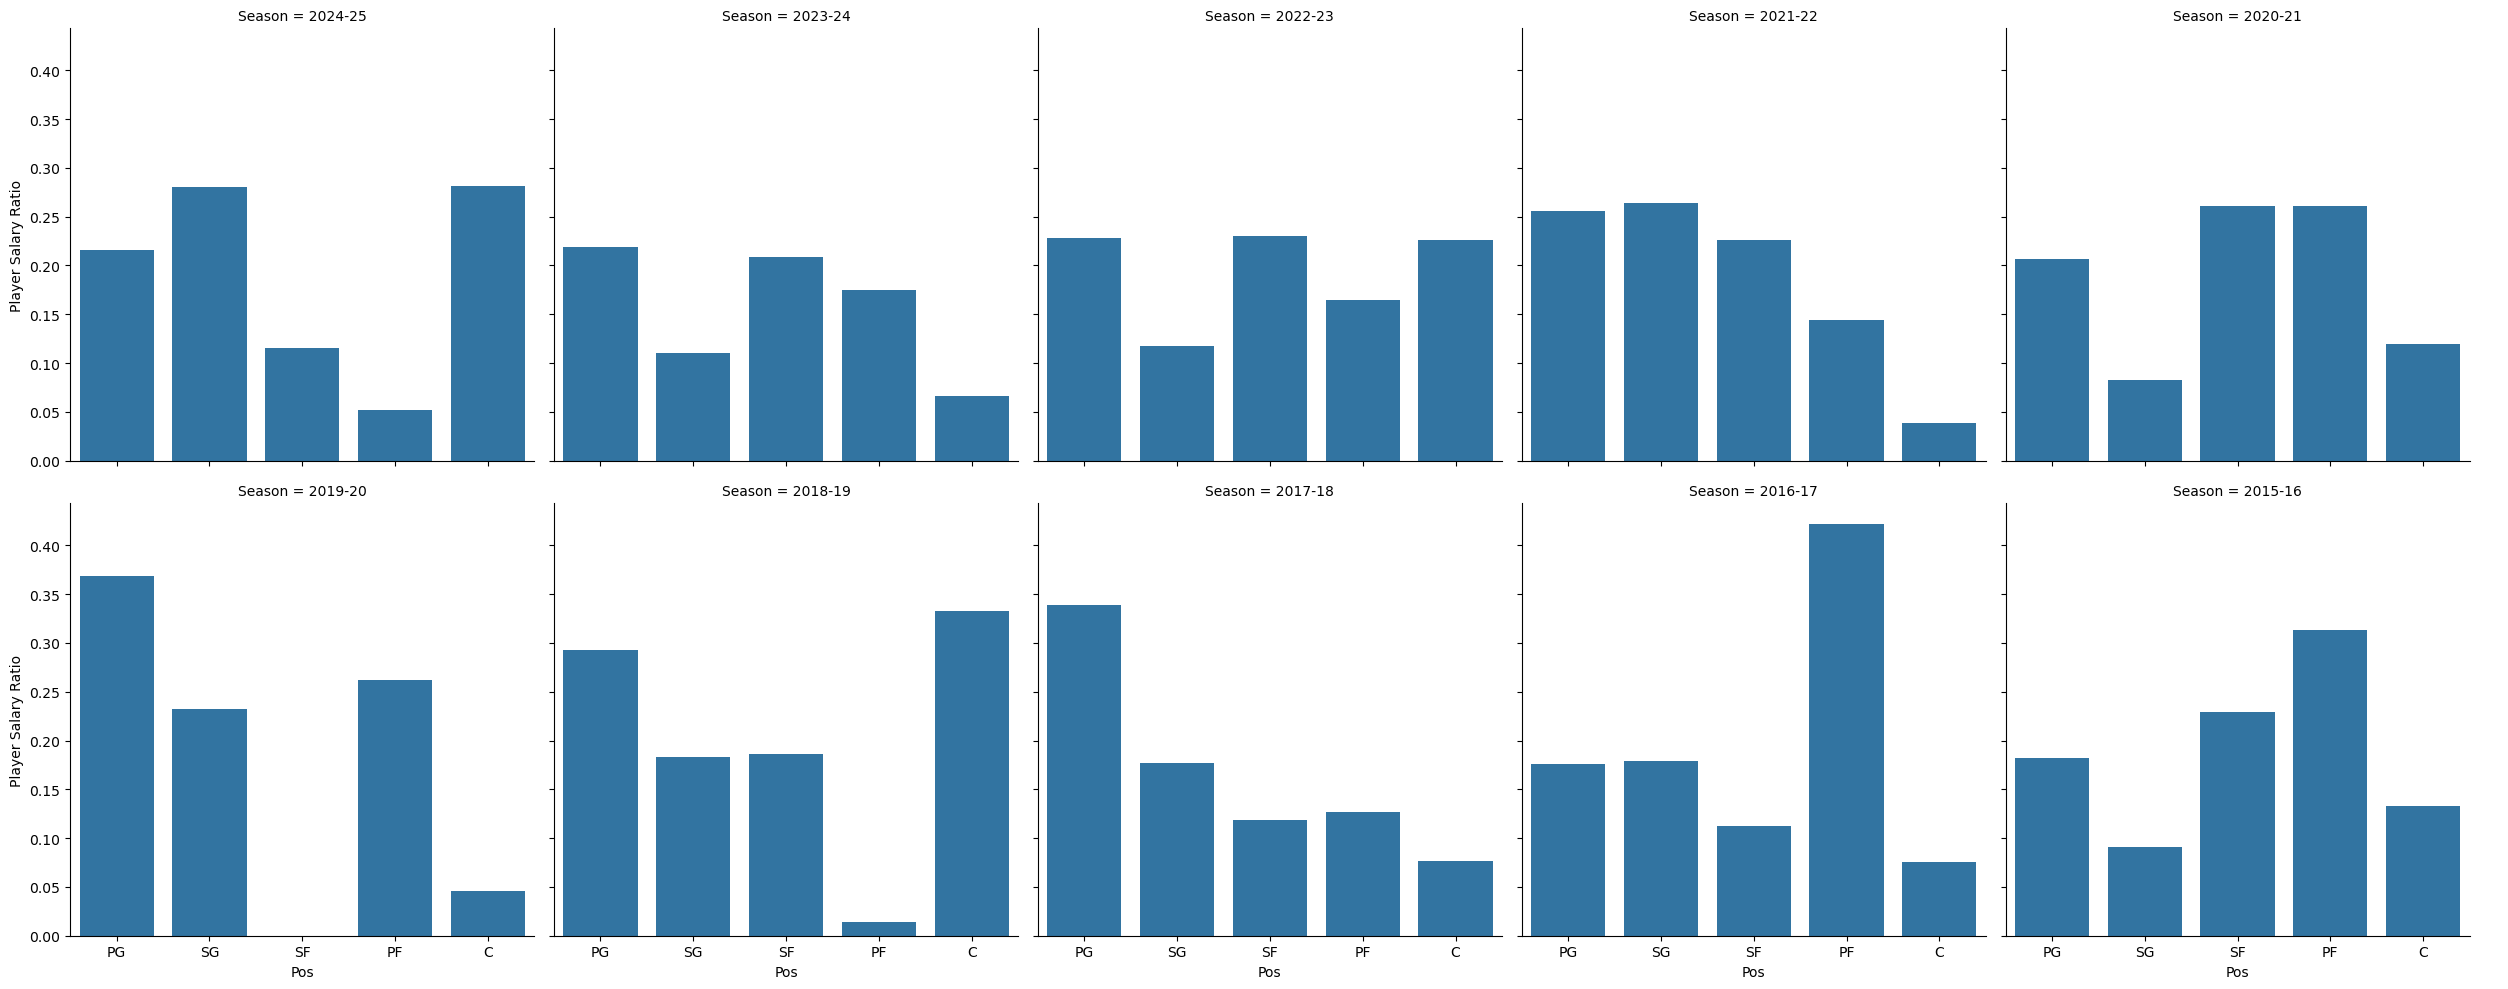

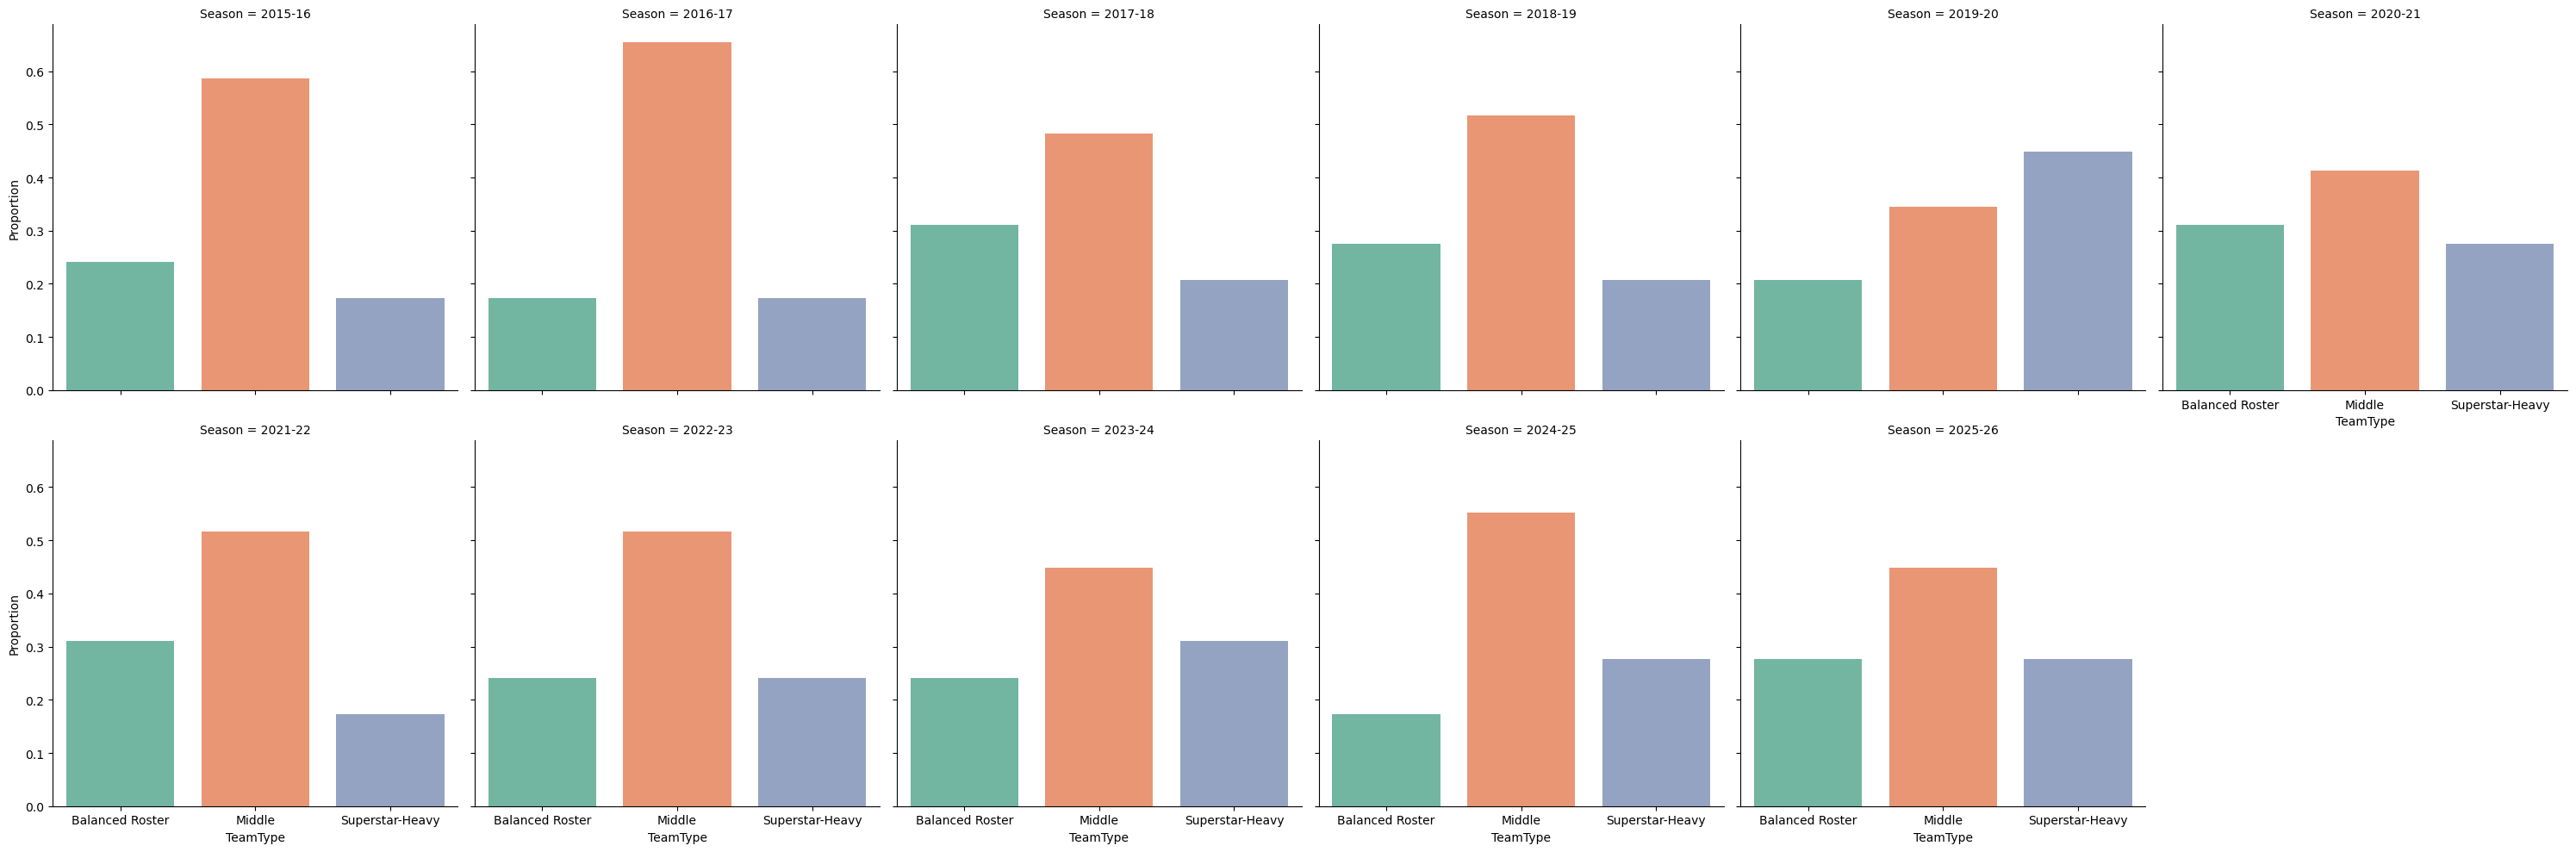

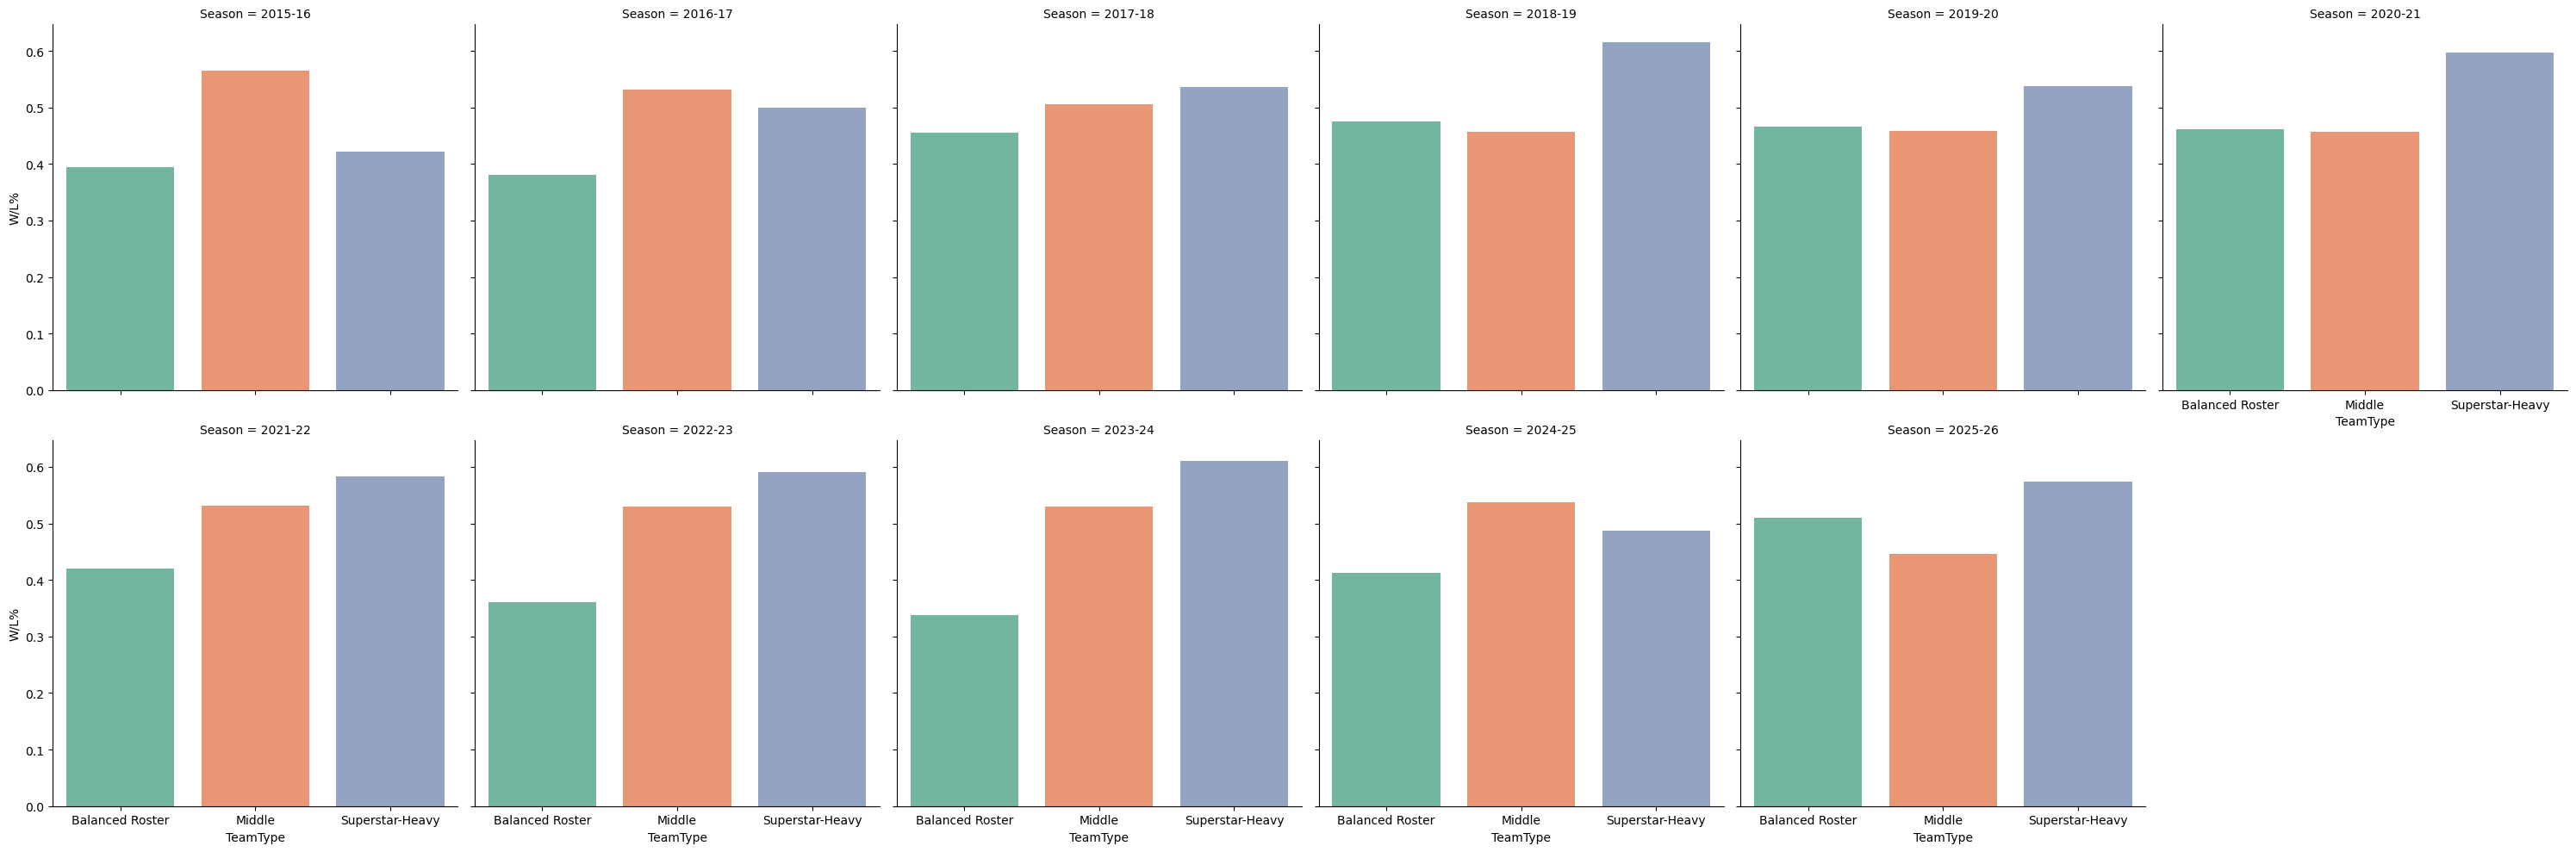

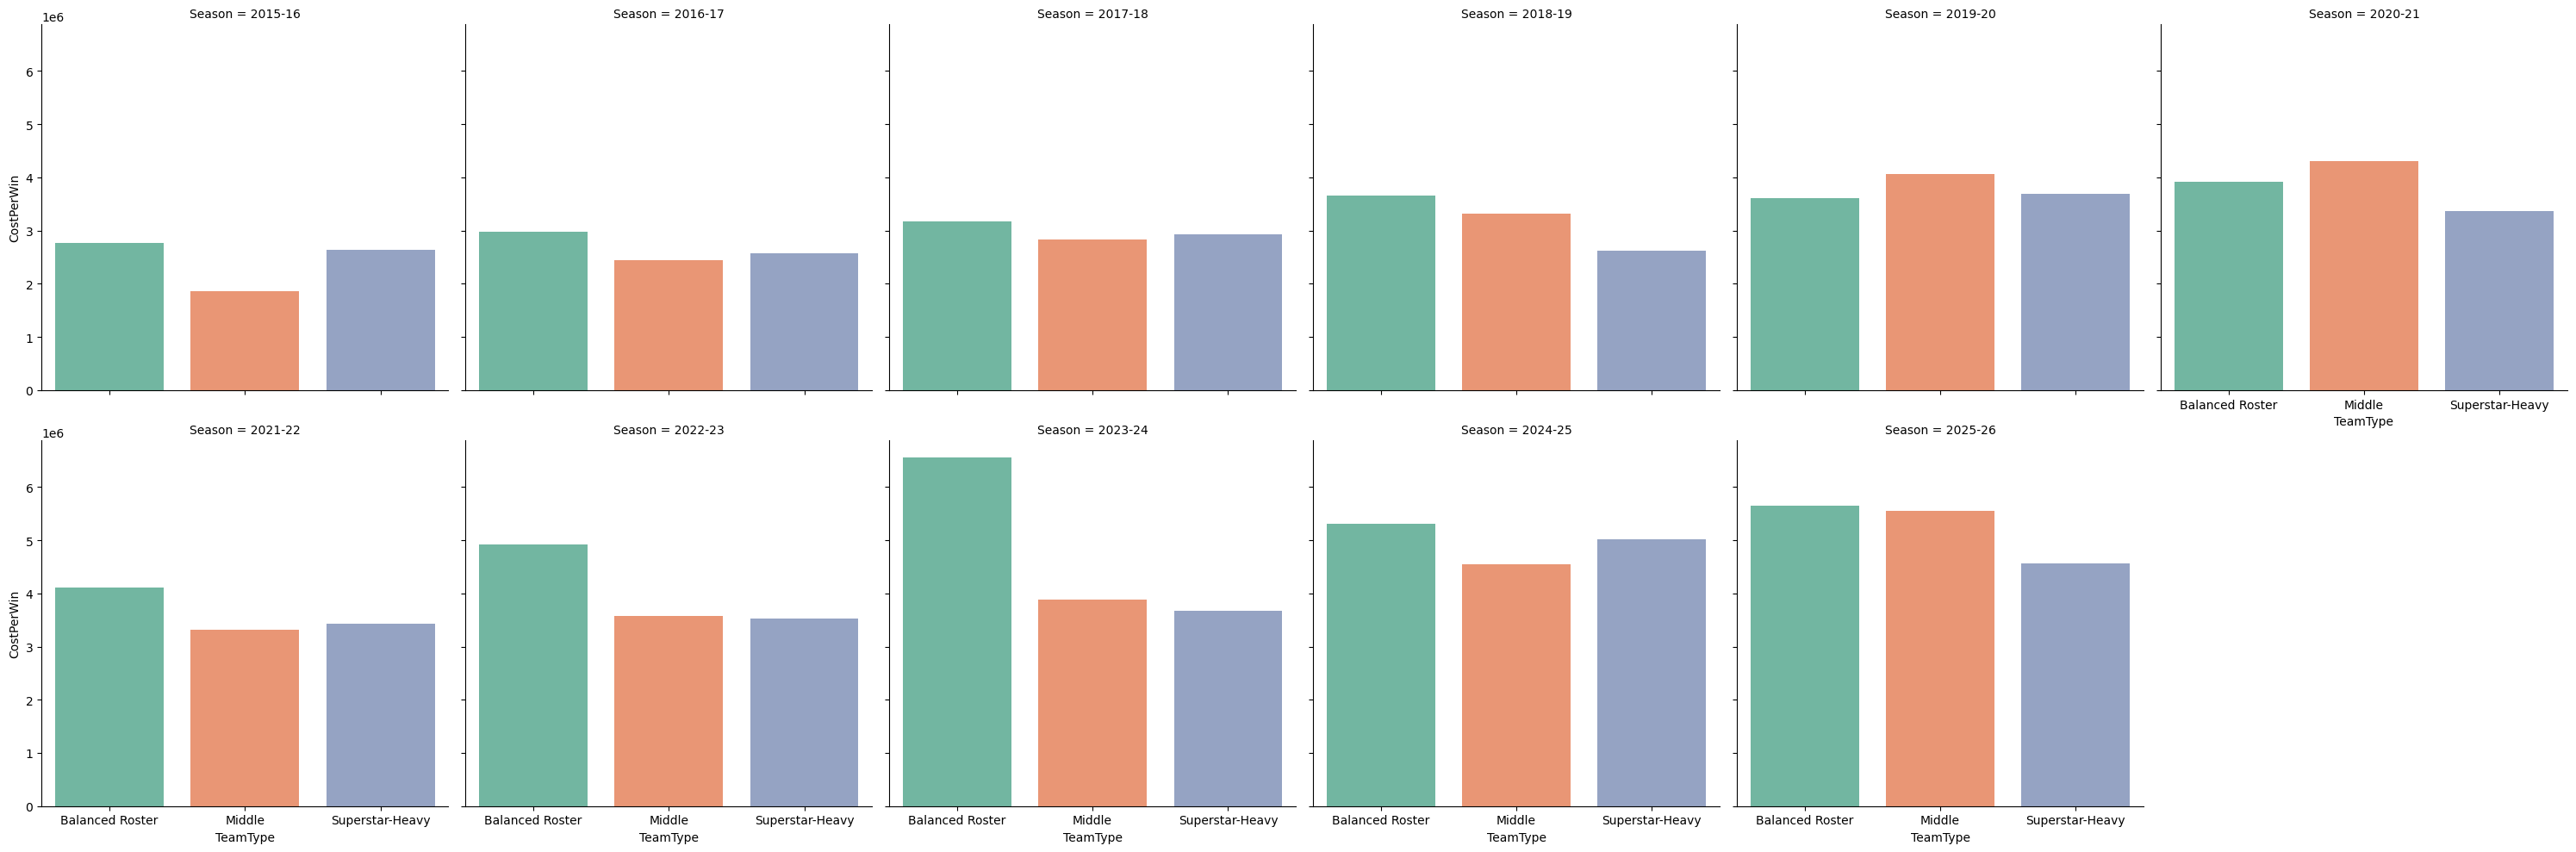

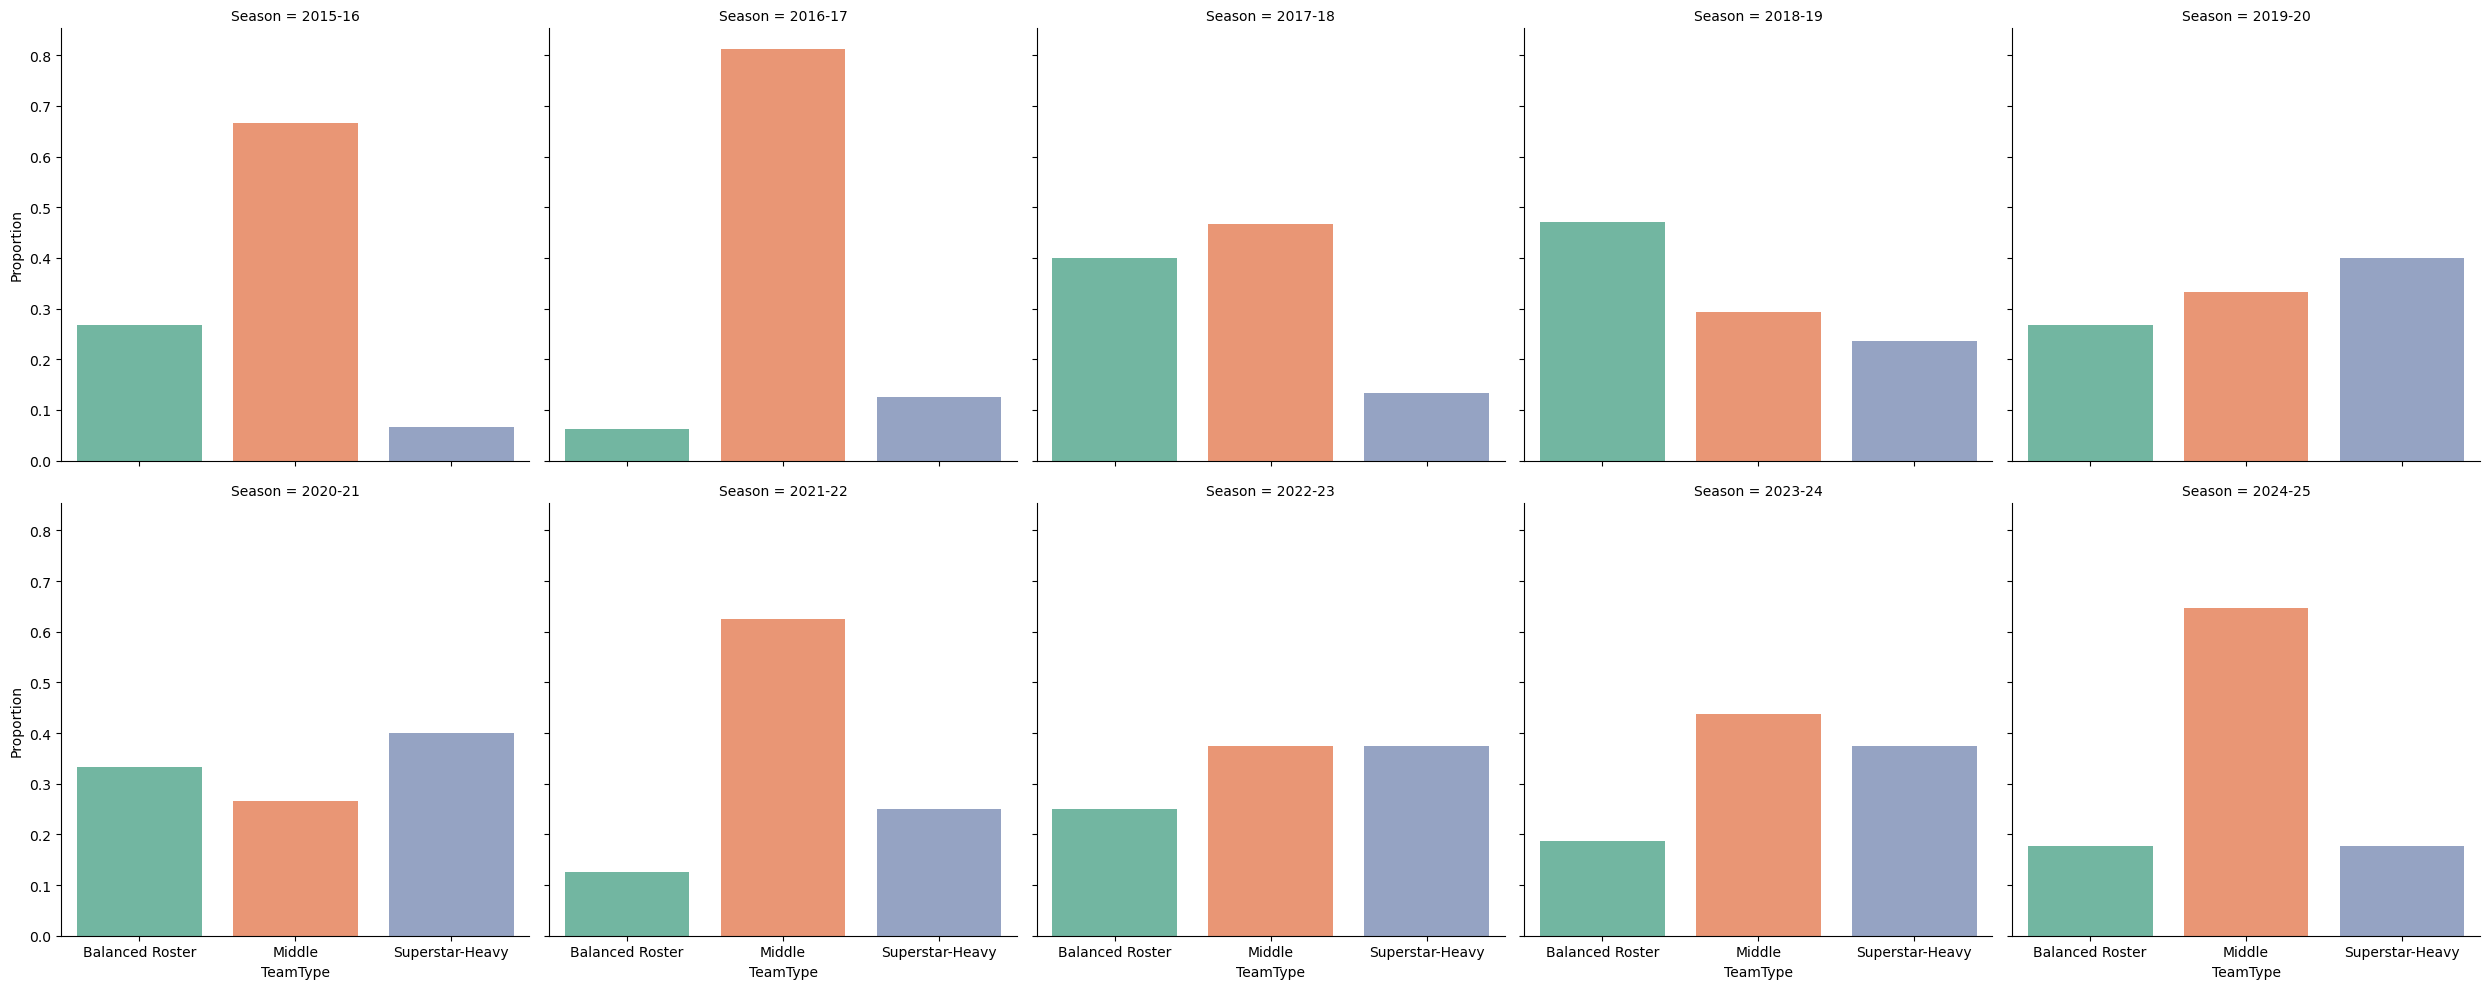

In [20]:
sns.relplot(data=t_regular_szn_data, x="Salary", y='W/L%', col='Season', col_wrap=6)

sns.catplot(data=t_playoff_data, x="W", y='Salary Ranking', col='Season', hue='Champ', col_wrap=5, kind='bar', errorbar=None)

sns.catplot(data=p_regular_szn_data, x="Pos", y="Salary", col="Season", col_wrap=6, kind="box", order=['PG', 'SG', 'SF', 'PF', 'C'])

sns.catplot(data=championship_salaries, x='Pos', y='Player Salary Ratio', col='Season', col_wrap=5, kind='bar', estimator='sum', errorbar=None, order=['PG', 'SG', 'SF', 'PF', 'C'])

# cj's plots
sns.catplot(
    data=prop_df_reg,
    x="TeamType",
    y="Proportion",
    hue="TeamType",
    kind="bar",
    col="Season",
    col_wrap=6,
    order=["Balanced Roster", "Middle", "Superstar-Heavy"],
    palette="Set2",
    legend=False
)

g = sns.catplot(
    data=analysis_df_reg,
    x="TeamType",
    y="W/L%",
    hue="TeamType",
    kind="bar",
    col="Season",
    col_wrap=6,
    order=["Balanced Roster", "Middle", "Superstar-Heavy"],
    palette="Set2",
    errorbar=None,
    legend=False
)

g = sns.catplot(
    data=analysis_df_reg,
    x="TeamType",
    y="CostPerWin",
    hue="TeamType",
    kind="bar",
    col="Season",
    col_wrap=6,
    order=["Balanced Roster", "Middle", "Superstar-Heavy"],
    palette="Set2",
    errorbar=None,
    legend=False
)

sns.catplot(data=prop_df_playoff, x='TeamType', y="Proportion", hue='TeamType', kind="bar", col="Season", col_wrap=5, order=["Balanced Roster", "Middle", "Superstar-Heavy"], palette="Set2", errorbar=None, legend=False)